In [1]:
#| hide
# BASED ON
  # Kalman filtering and smoothing_ANNO^V4.ipynb
  # Kalman filtering and smoothing_ANNO^V3.ipynb
  # Kalman filtering and smoothing_ANNO^V2.ipynb
  # Kalman filtering and smoothing_ANNO^V1.ipynb
  # GP regression by SSM.ipynb

# DONE
# v1 starts ------------------------------------------------
# migrated to RxInfer 3.0.0
# brought over my changes from RxInfer v2.16.2
# Use \mathbf for structures
# x_tL1 & w_tL1 with nice subscripts
# v2 starts ------------------------------------------------
# \mathcal{P} & \mathcal{Q} --> \mathbf{P} & \mathbf{Q}
# insert f() & g() functions
  # works with generating data; took out again to rather have same in both places
  # does NOT work inside @model (same as https://learnableloop.ai/posts/WeightVsHeight_BLOG.html)
    # seems to take literal symbols in the code to build FFG, so
      # x[t] ~ MvNormalMeanCovariance(f(A= A, xₜ₋₁= xₜ₋₁) does not work
# generate_data() --> sim_point_data
# for 'system identification' section: x --> v
  # the 'x' here is not associated with state but just a name for one of the signals
  # 'v' will go better with the other signal called 'w'
# s (for sum, in 'system identification' section) --> z
  # need s for state (which still need to be changed)
# v3 starts ------------------------------------------------
# change x --> s (for state)
# add tildes to hidden state
# v4 starts ------------------------------------------------
# switch roles of A & B
# change P matrix to R matrix
# clean up missing data section
# standardize symbols to DeVries
# have fp() & fr() in envir, but not in agent
  # maybe in future can remove fp() & fr() from envir too
      # so that they look more similar
      # however, I need to have fp() & fr() implemented somewhere 
# v5 starts ------------------------------------------------
# split into 3 parts
# clean

# TODO
# insert (modified) CRISP-DM structure
# replace code vars with math symbols
  # makes mapping between literature and code better to enhance understanding
  # make expressions more concise due to reduced wordyness
# replace hardcoded parameters with symbols


In [2]:
versioninfo() ##. Julia version

Julia Version 1.10.5
Commit 6f3fdf7b362 (2024-08-27 14:19 UTC)
Build Info:
  Official https://julialang.org/ release
Platform Info:
  OS: Linux (x86_64-linux-gnu)
  CPU: 12 × Intel(R) Core(TM) i7-8700B CPU @ 3.20GHz
  WORD_SIZE: 64
  LIBM: libopenlibm
  LLVM: libLLVM-15.0.7 (ORCJIT, skylake)
Threads: 1 default, 0 interactive, 1 GC (on 12 virtual cores)
Environment:
  JULIA_NUM_THREADS = 


In [3]:
# Activate local environment, see `Project.toml`
# import Pkg; Pkg.activate(".."); Pkg.instantiate();
import Pkg
Pkg.add(Pkg.PackageSpec(;name="RxInfer"))
Pkg.add("Plots")
Pkg.add("StableRNGs")
Pkg.add("LaTeXStrings")
Pkg.add("Distributions")

# using RxInfer, BenchmarkTools, Random, LinearAlgebra, Plots, LaTeXStrings, Distributions, StableRNGs
using RxInfer, Random, Plots, StableRNGs, LaTeXStrings, Distributions

   Resolving package versions...
  No Changes to `~/.julia/environments/v1.10/Project.toml`
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.10/Project.toml`
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.10/Project.toml`
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.10/Project.toml`
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.10/Project.toml`
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`


In [4]:
Pkg.status()

Status `~/.julia/environments/v1.10/Project.toml`
  [31c24e10] Distributions v0.25.112
  [b964fa9f] LaTeXStrings v1.3.1
  [91a5bcdd] Plots v1.40.8
  [86711068] RxInfer v3.7.1
  [860ef19b] StableRNGs v1.0.2


# Kalman filtering and smoothing

In the following set of examples the goal is to estimate hidden <u>states</u> of a Dynamical process where all hidden states are Gaussians.

We start our journey with a simple 

- (1) multivariate Linear Gaussian State Space Model (LGSSM), which can be solved analytically. We then solve an 
- (2) identification problem which does not have an analytical solution. Utimately, we show how **RxInfer.jl** can 
- (3) deal with missing observations.

# 2 System Identification Problem

In this example we are going to attempt to run Bayesian inference and decouple two random-walk signals, which were combined into a single through some deterministic function `f`. We do not have access to the real values of these signals, but only to their combination. First, we create the `sim_batch_data` function that accepts `f` as an argument. 

The function returns the real signals `s̃₁` and  `s̃₂` for later comparison (we are not going to use them during inference) and their combined version `y` (we are going to use it as our observations during the inference). We also assume that `y` is corrupted with some measurement noise.

## Combination 1: $y = \tilde{s}_1 + \tilde{s}_2$

In our first example, we are going to use a simple addition (`+`) as the function `f`. In general, it is impossible to decouple the signals `s̃₁` and `s̃₂` without strong priors, but we can try and see how good an inference can be. The `+` operation on two random variables also has a special meaning in the probabilistic inference, namely the convolution of pdf's of the two random variables, and `RxInfer` treats it specially with many precomputed analytical rules, which may make the inference task easier. First, let us create a test dataset:

In [5]:
_s̃₁₍ₜ₋₁₎ = -20.0
_s̃₂₍ₜ₋₁₎ = 20.0
_τ̃_s₁ = 0.1
_τ̃_s₂ = 1.0
_σ̃²ᵥ = 20.0 ##observation noise
_T = 250

250

### The Generative Process

#### Provision function ($f_p$)
The *provision* function, provides another covariate vector. Because this is a *sequential* system, the provision function defines the transition between the previous state and the current state. This special case of the provision function is known as a *transition* function:

$$\tilde{p}_{1t} = f_p(\tilde{s}_{1,t-1}) = \tilde{s}_{1,t-1}$$

$$\tilde{p}_{2t} = f_p(\tilde{s}_{2,t-1}) = \tilde{s}_{2,t-1}$$

When we add *system noise* the next *state* is produced:

$$\tilde{s}_{1t} = \mathcal{N}(\tilde{p}_{1t}, \tilde{\tau}_{s_1})$$

$$\tilde{s}_{2t} = \mathcal{N}(\tilde{p}_{2t}, \tilde{\tau}_{s_2})$$

The `tilde`s indicate that the parameters and variables are hidden and not observed.

In [6]:
## provision function, provides another covariate vector
function fₚ(; s̃ₜ₋₁)
    return s̃ₜ₋₁
end
fₚ(s̃ₜ₋₁=_s̃₁₍ₜ₋₁₎), fₚ(s̃ₜ₋₁=_s̃₂₍ₜ₋₁₎) 

(-20.0, 20.0)

#### Response function ($f_r$)
The *response* function, provides the response to the covariate vector.
$$\tilde{r}_{t} = f_r(\tilde{s}_{1t}, \tilde{s}_{2t}) = f(\tilde{s}_{1t}, \tilde{s}_{2t}) = \tilde{s}_{1t} + \tilde{s}_{2t} $$

After combining with *observation noise* the *observation* is produced:

$$y_{t} = \mathcal{N}(\tilde{r}_{t}, \tilde{\sigma}^2_V)$$


The `tilde`s indicate that the parameters and variables are hidden and not observed.

In [7]:
## response function, provides the response to covariate vector
function fᵣ(; f, s̃₁ₜ, s̃₂ₜ)
    return f(s̃₁ₜ, s̃₂ₜ)
end
fᵣ(; f=+, s̃₁ₜ=7.0, s̃₂ₜ=8.0)

15.0

In [8]:
## Data comes from either a simulation/lab (sim|lab) OR from the field (fld)
## Data are handled either in batches (batch) OR online as individual points (point)
## Batch data accumulates either
    ## along the depth/examples dimension/axis (into the screen/page), OR
        ## typical for supervised & unsupervised learning
    ## along the time dimension/axis (down the screen page)
        ## typical for sequential decision learning (reinforcement learning & active inference)
function sim_batch_data(f, T; seed=123, s̃₁₍ₜ₋₁₎, s̃₂₍ₜ₋₁₎, τ̃_s₁, τ̃_s₂, σ̃²ᵥ)
    rng = StableRNG(seed)
    p̃₁ = Vector{Float64}(undef, T)
    s̃₁ = Vector{Float64}(undef, T)
    p̃₂ = Vector{Float64}(undef, T)
    s̃₂ = Vector{Float64}(undef, T)
    r̃ = Vector{Float64}(undef, T)
    y = Vector{Float64}(undef, T)
    for t in 1:T
        p̃₁[t] = fₚ(s̃ₜ₋₁=s̃₁₍ₜ₋₁₎)
        s̃₁[t] = rand(rng, Normal(p̃₁[t], sqrt(1.0/τ̃_s₁)))
        p̃₂[t] = fₚ(s̃ₜ₋₁=s̃₂₍ₜ₋₁₎)
        s̃₂[t] = rand(rng, Normal(p̃₂[t], sqrt(1.0/τ̃_s₂)))
        r̃[t] = fᵣ(f=f, s̃₁ₜ=s̃₁[t], s̃₂ₜ=s̃₂[t])
        y[t] = rand(rng, Normal(r̃[t], sqrt(σ̃²ᵥ)))
        s̃₁₍ₜ₋₁₎ = s̃₁[t]
        s̃₂₍ₜ₋₁₎ = s̃₂[t]
    end
    return s̃₁, s̃₂, y
end

sim_batch_data (generic function with 1 method)

In [9]:
_s̃₁, _s̃₂, _y = sim_batch_data(
    +, _T; 
    s̃₁₍ₜ₋₁₎=_s̃₁₍ₜ₋₁₎, s̃₂₍ₜ₋₁₎=_s̃₂₍ₜ₋₁₎, 
    τ̃_s₁=_τ̃_s₁, τ̃_s₂=_τ̃_s₂, 
    σ̃²ᵥ=_σ̃²ᵥ);

In [10]:
_s̃₁

250-element Vector{Float64}:
 -20.401095992460988
 -20.669875759133884
 -22.790697414814776
 -27.104638760134062
 -31.248220640067366
 -26.079608998684243
 -27.11512896946521
 -30.294795287103234
 -32.698280013763174
 -34.850070378118104
   ⋮
 -54.42533877570402
 -52.38587391024251
 -52.85091503729493
 -56.78914098796256
 -55.32020135002518
 -57.28044133233906
 -59.6499029990486
 -59.74600957488878
 -59.32390477663594

In [11]:
_s̃₂

250-element Vector{Float64}:
 20.666885172487124
 20.57261116763893
 19.857870775719412
 18.858298515749894
 19.81453408886256
 20.425064540658344
 19.918312704314683
 19.372737596030216
 18.846506733028683
 19.028263308009453
  ⋮
 52.195724854526475
 52.15806523930519
 50.846307575145
 51.655335116038906
 50.10235490650183
 50.4547248217021
 51.8221505241864
 49.89530546131343
 49.41021524826118

In [12]:
_y

250-element Vector{Float64}:
  -5.353952716032312
   4.275970805667579
  -7.258265483265913
 -14.918691611380964
  -2.289681163005755
  -3.2075768172574284
  -2.526501156230419
  -7.968874122573138
 -15.558887021638972
 -18.922064684720848
   ⋮
  -5.730263980041214
  -7.608774757258874
   0.8729760214719698
  -8.777046520647453
  -6.9699809935290045
  -8.267463283992132
  -1.8915218553802293
 -11.710160406427732
 -17.391946039775874

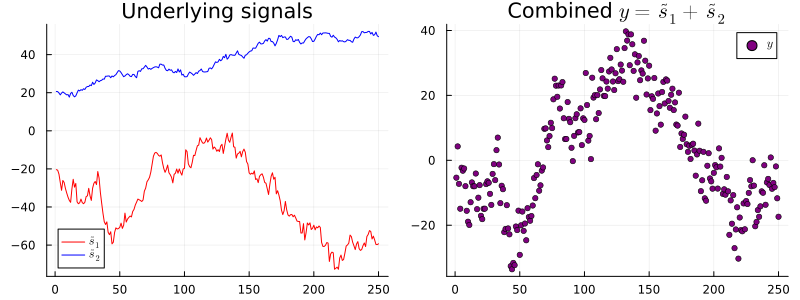

In [13]:
_pl = plot(title="Underlying signals")
_pl = plot!(_pl, _s̃₁, label=L"\tilde{s}_1", c="red")
_pl = plot!(_pl, _s̃₂, label=L"\tilde{s}_2", c="blue")
_pr = plot(title="Combined " * L"y = \tilde{s}_1 + \tilde{s}_2")
_pr = scatter!(_pr, _y, ms=3, color=:purple, label=L"y")
plot(_pl, _pr, size=(800, 300))

### The Generative Model

To run inference, we need to create a probabilistic model: our beliefs about how our data could have been generated. For this we can use the `@model` macro from `RxInfer.jl`:

In [14]:
@model function identification_problem(f, y, m₁₀, τ₁₀, a₁, b₁, m₂₀, τ₂₀, a₂, b₂, a_y, b_y)
    s₁₀ ~ Normal(mean=m₁₀, precision=τ₁₀)
    τ_s₁ ~ Gamma(shape=a₁, rate=b₁)
    s₂₀ ~ Normal(mean=m₂₀, precision=τ₂₀)
    τ_s₂ ~ Gamma(shape=a₂, rate=b₂)
    τ_y ~ Gamma(shape=a_y, rate=b_y)
    s₁₍ₜ₋₁₎ = s₁₀
    s₂₍ₜ₋₁₎ = s₂₀
    local s₁
    local s₂
    local z
    for t in 1:length(y)
        s₁[t] ~ Normal(mean=s₁₍ₜ₋₁₎, precision=τ_s₁)
        s₂[t] ~ Normal(mean=s₂₍ₜ₋₁₎, precision=τ_s₂)
        z[t] ~ f(s₁[t], s₂[t])
        y[t] ~ Normal(mean=z[t], precision=τ_y)
        s₁₍ₜ₋₁₎ = s₁[t]
        s₂₍ₜ₋₁₎ = s₂[t]
    end
end

`RxInfer` runs Bayesian inference as a variational optimisation procedure between the real solution and its variational proxy `q`. In our model specification we assumed noise components to be unknown, thus, we need to enforce a structured mean-field assumption for the variational family of distributions `q`. This inevitably reduces the accuracy of the result, but makes the task easier and allows for fast and analytical message passing-based variational inference:

In [15]:
_constraints = @constraints begin
    q(s₁₀, s₂₀, s₁, s₂, τ_s₁, τ_s₂, τ_y, z) = q(s₁, s₁₀, s₂, s₂₀, z)q(τ_s₂)q(τ_s₁)q(τ_y)
end

Constraints: 
  q(s₁₀, s₂₀, s₁, s₂, τ_s₁, τ_s₂, τ_y, z) = q(s₁, s₁₀, s₂, s₂₀, z)q(τ_s₂)q(τ_s₁)q(τ_y)


The next step is to assign priors, initialise needed messages and marginals and call the `inference` function:

In [16]:
_m₁₀, _τ₁₀ = -20.0, 1.0
_m₂₀, _τ₂₀ = 20.0, 1.0

## We set relatively strong priors for random walk noise components
## and sort of vague prior for the noise of the observations
_a₁, _b₁ = 0.01, 0.01var(_s̃₁)
_a₂, _b₂ = 0.01, 0.01var(_s̃₂)
_a_y, _b_y = 1.0, 1.0

## We set relatively strong priors for messages
_s₁_init = map(r -> NormalMeanPrecision(r, _τ₁₀), reverse(range(-60, -20, length=_T)))
_s₂_init = map(r -> NormalMeanPrecision(r, _τ₂₀), range(20, 60, length=_T))

_init = @initialization begin
    μ(s₁) = _s₁_init
    μ(s₂) = _s₂_init
    q(τ_s₁) = GammaShapeRate(_a₁, _b₁)
    q(τ_s₂) = GammaShapeRate(_a₂, _b₂)
    q(τ_y) = GammaShapeRate(_a_y, _b_y)
end

_result = infer(
    model = identification_problem(
        f=+, 
        m₁₀=_m₁₀, τ₁₀=_τ₁₀, a₁=_a₁, b₁=_b₁, 
        m₂₀=_m₂₀, τ₂₀=_τ₂₀, a₂=_a₂, b₂=_b₂, 
        a_y=_a_y, b_y=_b_y),
    data  = (y = _y,), 
    options = (limit_stack_depth = 500, ), 
    constraints = _constraints, 
    initialization = _init,
    iterations = 50
)

Inference results:
  Posteriors       | available for (s₂, τ_s₂, s₁₀, s₂₀, τ_s₁, s₁, z, τ_y)


In [18]:
_result.posteriors

Dict{Symbol, Vector} with 8 entries:
  :s₂   => Vector{NormalWeightedMeanPrecision{Float64}}[[NormalWeightedMeanPrec…
  :τ_s₂ => GammaShapeRate{Float64}[GammaShapeRate{Float64}(a=125.01, b=129.061)…
  :s₁₀  => NormalWeightedMeanPrecision{Float64}[NormalWeightedMeanPrecision{Flo…
  :s₂₀  => NormalWeightedMeanPrecision{Float64}[NormalWeightedMeanPrecision{Flo…
  :τ_s₁ => GammaShapeRate{Float64}[GammaShapeRate{Float64}(a=125.01, b=132.021)…
  :s₁   => Vector{NormalWeightedMeanPrecision{Float64}}[[NormalWeightedMeanPrec…
  :z    => Vector{NormalWeightedMeanPrecision{Float64}}[[NormalWeightedMeanPrec…
  :τ_y  => GammaShapeRate{Float64}[GammaShapeRate{Float64}(a=126.0, b=260.683),…

Let's examine our inference results:

In [19]:
_τ_s₁_marginals = _result.posteriors[:τ_s₁]
_τ_s₂_marginals = _result.posteriors[:τ_s₂]
_τ_y_marginals = _result.posteriors[:τ_y]

_z_marginals = _result.posteriors[:z]
_s₁_marginals = _result.posteriors[:s₁]
_s₂_marginals = _result.posteriors[:s₂];

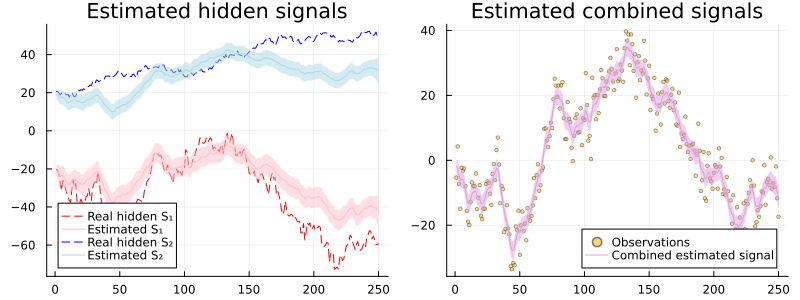

In [20]:
_p1 = plot(legend=:bottomleft, title="Estimated hidden signals")
_p2 = plot(legend=:bottomright, title="Estimated combined signals")

_p1 = plot!(_p1, _s̃₁, label="Real hidden S₁", c="red", linestyle=:dash)
_p1 = plot!(_p1, mean.(_s₁_marginals[end]), ribbon=var.(_s₁_marginals[end]), label="Estimated S₁", color=:pink)

_p1 = plot!(_p1, _s̃₂, label="Real hidden S₂", color=:blue, linestyle=:dash)
_p1 = plot!(_p1, mean.(_s₂_marginals[end]), ribbon=var.(_s₂_marginals[end]), label="Estimated S₂", color=:lightblue)

_p2 = scatter!(_p2, _y, label="Observations", ms=2, alpha=0.5, color=:orange)
_p2 = plot!(_p2, mean.(_z_marginals[end]), ribbon=std.(_z_marginals[end]), label="Combined estimated signal", color="plum")

plot(_p1, _p2, size=(800, 300))

The inference results are not so bad, even though `RxInfer` missed the correct values of the signals between `100` and `150`.

## Combination 2: $y = \mathrm{min}(\tilde{s}_1, \tilde{s}_2)$

In this example we use a slightly more complex function, for which `RxInfer` does not have precomputed analytical message update rules. We are going to attempt to run Bayesian inference with `min` as a combination function. Note, however, that directly using `min` may cause problems for the built-in approximation methods as it has zero partial derviates with respect to all but one of the variables. 

### The Generative Process

In [21]:
_s̃₁₍ₜ₋₁₎ = 0.0
_s̃₂₍ₜ₋₁₎ = 0.0
_τ̃_s₁ = 1.0
_τ̃_s₂ = 1.0
_σ̃²ᵥ = 1.0 ## observation noise
_T = 200

200

In [22]:
_min_s̃₁, _min_s̃₂, _min_y = sim_batch_data(
    min, _T; 
    seed=1, 
    s̃₁₍ₜ₋₁₎=_s̃₁₍ₜ₋₁₎, s̃₂₍ₜ₋₁₎=_s̃₂₍ₜ₋₁₎, 
    τ̃_s₁=_τ̃_s₁, τ̃_s₂=_τ̃_s₂, 
    σ̃²ᵥ=_σ̃²ᵥ);

In [23]:
_min_s̃₁

200-element Vector{Float64}:
 -0.5325200748641231
 -1.3760574787383777
 -0.34376400643438854
 -0.09683736607523746
 -1.9500360726184451
 -1.7178925137280041
 -0.5114889405789891
  0.9799054887699994
  1.4738614452691385
  0.21583988918877006
  ⋮
 11.635994703121376
 10.924903891533114
 12.101086505558115
 12.23488278202865
 14.24470601685975
 16.68915952947985
 15.21355198384941
 17.49518040732118
 16.88853455216658

In [24]:
_min_s̃₂

200-element Vector{Float64}:
  0.098465514284785
 -1.9153638413463216
 -1.2397977422271311
 -2.740326889546081
 -3.0775177160930336
 -2.5211723474749315
 -3.1417645469162077
 -3.8175642158895347
 -3.403893528229725
 -3.944508580769285
  ⋮
  2.9447026640735814
  3.343236550774581
  1.7153229626545394
  3.1612860855506497
  3.464740837552133
  4.966929654823941
  5.590221124459778
  6.156878620294983
  5.219136120500052

In [25]:
_min_y

200-element Vector{Float64}:
  0.22036644726040033
 -2.1851714825434487
 -1.1576369146831669
 -2.411694880333956
 -3.0418551997138934
 -3.5489933567433987
 -2.529456341036421
 -4.568787926083518
 -2.8472451081518817
 -4.672624206001446
  ⋮
  2.7076738085196226
  3.5105327668426
  2.1476892369392173
  4.2435567676856065
  4.165753448418778
  3.584702727331395
  6.14602156701984
  7.5620630212942235
  6.086359625031924

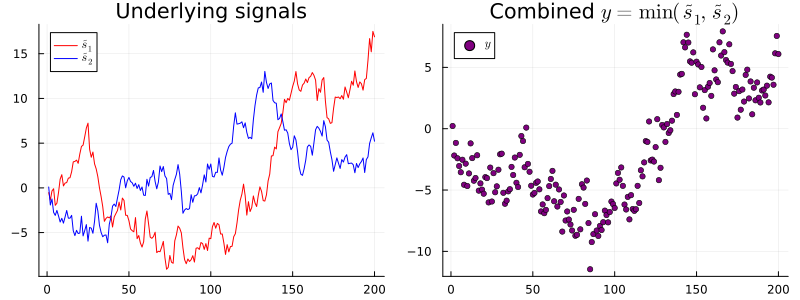

In [26]:
_pl = plot(title = "Underlying signals")
_pl = plot!(_pl, _min_s̃₁, label=L"\tilde{s}_1", c=:red)

_pl = plot!(_pl, _min_s̃₂, label=L"\tilde{s}_2", c=:blue)

_pr = plot(title = "Combined " * L"y = \mathrm{min}(\tilde{s}_1, \tilde{s}_2)")
_pr = scatter!(_pr, _min_y, ms=3, color=:purple, label=L"y")

plot(_pl, _pr, size = (800, 300))

### The Generative Model

We generate data with the `min` function directly, however we model it with a somewhat smoothed version:

In [27]:
## Smoothed version of `min` without zero-ed derivatives
function smooth_min(x, y)    
    if x < y
        return x + 1e-4*y
    else
        return y + 1e-4*x
    end
end

smooth_min (generic function with 1 method)

`RxInfer` supports arbitrary nonlinear functions, but it requires an explicit approximation method specification. That can be achieved with the built-in `@meta` macro:

In [28]:
_min_meta = @meta begin 
    ## In this example we are going to use a simple `Linearization` method
    smooth_min() -> Linearization()
end

Meta: 
  smooth_min() -> Linearization()


In [30]:
_min_m₁₀, _min_τ₁₀ = -1.0, 1.0
_min_m₂₀, _min_τ₂₀ = 1.0, 1.0

_min_a₁, _min_b₁ = 1.0, 1.0
_min_a₂, _min_b₂ = 1.0, 1.0
_min_a_y, _min_b_y = 1.0, 1.0

_init = @initialization begin
    μ(s₁) = NormalMeanPrecision(_min_m₁₀, _min_τ₁₀)
    μ(s₂) = NormalMeanPrecision(_min_m₂₀, _min_τ₂₀)
    q(τ_s₁) = GammaShapeRate(_min_a₁, _min_b₁)
    q(τ_s₂) = GammaShapeRate(_min_a₂, _min_b₂)
    q(τ_y) = GammaShapeRate(_min_a_y, _min_b_y)
end

_min_result = infer(
    model = identification_problem(
        f=smooth_min, 
        m₁₀=_min_m₁₀, τ₁₀=_min_τ₁₀, a₁=_min_a₁, b₁=_min_b₁, 
        m₂₀=_min_m₂₀, τ₂₀=_min_τ₂₀, a₂=_min_a₂, b₂=_min_b₂, 
        a_y=_min_a_y, b_y=_min_b_y),
    data  = (y = _min_y,), 
    options = (limit_stack_depth = 500, ), 
    constraints = _constraints, 
    initialization = _init,
    meta = _min_meta,
    iterations = 50
)

Inference results:
  Posteriors       | available for (s₂, τ_s₂, s₁₀, s₂₀, τ_s₁, s₁, z, τ_y)


In [31]:
_min_result.posteriors

Dict{Symbol, Vector} with 8 entries:
  :s₂   => Vector{NormalWeightedMeanPrecision{Float64}}[[NormalWeightedMeanPrec…
  :τ_s₂ => GammaShapeRate{Float64}[GammaShapeRate{Float64}(a=101.0, b=51.2907),…
  :s₁₀  => NormalWeightedMeanPrecision{Float64}[NormalWeightedMeanPrecision{Flo…
  :s₂₀  => NormalWeightedMeanPrecision{Float64}[NormalWeightedMeanPrecision{Flo…
  :τ_s₁ => GammaShapeRate{Float64}[GammaShapeRate{Float64}(a=101.0, b=51.2789),…
  :s₁   => Vector{NormalWeightedMeanPrecision{Float64}}[[NormalWeightedMeanPrec…
  :z    => Vector{NormalWeightedMeanPrecision{Float64}}[[NormalWeightedMeanPrec…
  :τ_y  => GammaShapeRate{Float64}[GammaShapeRate{Float64}(a=101.0, b=200.148),…

In [32]:
_min_τ_s₁_marginals = _min_result.posteriors[:τ_s₁]
_min_τ_s₂_marginals = _min_result.posteriors[:τ_s₂]
_min_τ_y_marginals = _min_result.posteriors[:τ_y]

_min_z_marginals = _min_result.posteriors[:z]
_min_s₁_marginals = _min_result.posteriors[:s₁]
_min_s₂_marginals = _min_result.posteriors[:s₂];

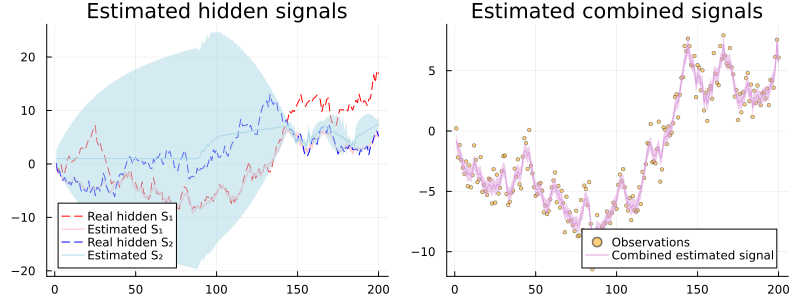

In [33]:
_p1 = plot(legend=:bottomleft, title="Estimated hidden signals")
_p2 = plot(legend=:bottomright, title="Estimated combined signals")

_p1 = plot!(_p1, _min_s̃₁, label="Real hidden S₁", c="red", linestyle=:dash)
_p1 = plot!(_p1, mean.(_min_s₁_marginals[end]), ribbon=var.(_min_s₁_marginals[end]), label="Estimated S₁", color=:pink)

_p1 = plot!(_p1, _min_s̃₂, label="Real hidden S₂", color=:blue, linestyle=:dash)
_p1 = plot!(_p1, mean.(_min_s₂_marginals[end]), ribbon=var.(_min_s₂_marginals[end]), label="Estimated S₂", color=:lightblue)

_p2 = scatter!(_p2, _min_y, label="Observations", ms=2, alpha=0.5, color=:orange)
_p2 = plot!(_p2, mean.(_min_z_marginals[end]), ribbon=std.(_min_z_marginals[end]), label="Combined estimated signal", color="plum")

plot(_p1, _p2, size=(800, 300))

As we can see inference with the `min` function is significantly harder. Even though the combined signal has been inferred with high precision the underlying `v` and `w` signals are barely inferred. This may be expected, since the `min` function essentially destroy the information about one of the signals, thus, making it impossible to decouple two seemingly identical random walk signals. The only one inferred signal is the one which is lower and we have no inference information about the signal which is above. It might be possible to infer the states, however, with more informative priors and structural information about two different signals (e.g. if these are not random walks). 

## Online (filtering) identification: $y = \mathrm{min}(\tilde{s}_1, \tilde{s}_2)$

Another way to approach this problem is to use online (filtering) inference procedure from `RxInfer`, but for that we also need to modify our model specification a bit:

### The Generative Process

Next step is to generate our dataset and to run the actual inference procedure! For that we use the `infer` function with `autoupdates` keyword:

In [34]:
_s̃₁₍ₜ₋₁₎ = 1.0
_s̃₂₍ₜ₋₁₎ = -1.0
_τ̃_s₁ = 1.0
_τ̃_s₂ = 1.0
_σ̃²ᵥ = 1.0 ##observation noise
_T = 300

300

In [35]:
_rx_s̃₁, _rx_s̃₂, _rx_y = sim_batch_data(
    min, _T; 
    seed=1, 
    s̃₁₍ₜ₋₁₎=_s̃₁₍ₜ₋₁₎, s̃₂₍ₜ₋₁₎=_s̃₂₍ₜ₋₁₎, 
    τ̃_s₁=_τ̃_s₁, τ̃_s₂=_τ̃_s₂, 
    σ̃²ᵥ=_σ̃²ᵥ);

In [36]:
_rx_s̃₁

300-element Vector{Float64}:
  0.4674799251358769
 -0.3760574787383777
  0.6562359935656115
  0.9031626339247625
 -0.9500360726184451
 -0.7178925137280042
  0.4885110594210108
  1.9799054887699992
  2.4738614452691383
  1.2158398891887698
  ⋮
 14.715705062022895
 15.13350407386025
 14.966386749228318
 15.005789040066146
 14.522153754344416
 13.542981339795244
 14.554317190702813
 12.879159788609714
 12.533966078243003

In [37]:
_rx_s̃₂

300-element Vector{Float64}:
  -0.901534485715215
  -2.9153638413463216
  -2.239797742227131
  -3.740326889546081
  -4.077517716093034
  -3.521172347474932
  -4.1417645469162085
  -4.8175642158895355
  -4.403893528229726
  -4.944508580769286
   ⋮
  -3.127596543119536
  -2.4904468534292046
  -2.41950024394849
  -2.8024522739003057
  -5.079038511589717
  -6.533981992409512
  -9.158210504701648
 -10.071390396703338
 -10.363573258463711

In [38]:
_rx_y

300-element Vector{Float64}:
  -0.14864796359069155
  -3.1851714825434487
  -2.1576369146831667
  -3.411694880333956
  -4.041855199713893
  -4.5489933567433996
  -3.529456341036422
  -5.568787926083519
  -3.8472451081518826
  -5.672624206001447
   ⋮
  -0.8757311338953824
  -1.7386965707479658
  -1.7192256893794404
  -2.799924492306463
  -3.534637117106459
  -5.694563357428694
 -10.969410855554415
  -9.983476577762598
 -11.66386107476468

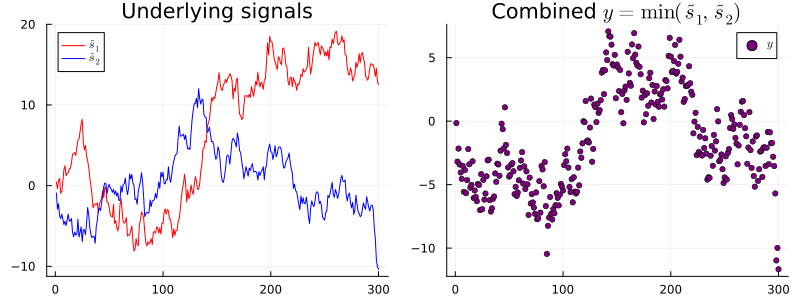

In [39]:
_pl = plot(title="Underlying signals")
_pl = plot!(_pl, _rx_s̃₁, label=L"\tilde{s}_1", c=:red)

_pl = plot!(_pl, _rx_s̃₂, label=L"\tilde{s}_2", c=:blue)

_pr = plot(title = "Combined " * L"y = \mathrm{min}(\tilde{s}_1, \tilde{s}_2)")
_pr = scatter!(_pr, _rx_y, ms=3, color=:purple, label=L"y")

plot(_pl, _pr, size=(800, 300))

### The Generative Model

Another way to approach to this problem is to use online (filtering) inference procedure from `RxInfer`, but for that we also need to modify our model specification a bit:

In [40]:
@model function rx_identification(f, y, m₁₀, τ₁₀, a₁, b₁, m₂₀, τ₂₀, a₂, b₂, a_y, b_y)
    ## We are going to continuosly update our priors
    ## based on new posteriors
    s₁₀ ~ Normal(mean=m₁₀, precision=τ₁₀)
    τ_s₁ ~ Gamma(shape=a₁, rate=b₁)
    s₂₀ ~ Normal(mean=m₂₀, precision=τ₂₀)
    τ_s₂ ~ Gamma(shape=a₂, rate=b₂)
    τ_y ~ Gamma(shape=a_y, rate=b_y)
    
    s₁ ~ Normal(mean= s₁₀, precision= τ_s₁)
    s₂ ~ Normal(mean = s₂₀, precision = τ_s₂)

    z ~ f(s₁, s₂)
    y ~ Normal(mean=z, precision=τ_y)
end

We impose structured mean-field assumption for this model as well:

In [41]:
_rx_constraints = @constraints begin
    q(s₁₀, s₁, s₂₀, s₂, τ_s₁, τ_s₂, τ_y, z) = q(s₁₀, s₁)q(s₂, s₂₀)q(τ_s₂)q(τ_s₁)q(z)q(τ_y)
end

Constraints: 
  q(s₁₀, s₁, s₂₀, s₂, τ_s₁, τ_s₂, τ_y, z) = q(s₁₀, s₁)q(s₂, s₂₀)q(τ_s₂)q(τ_s₁)q(z)q(τ_y)


Online inference in the `RxInfer` supports the `@autoupdates` specification, which tells inference procedure how to update priors based on new computed posteriors:

In [42]:
_autoupdates = @autoupdates begin
    m₁₀, τ₁₀ = mean_precision(q(s₁))
    m₂₀, τ₂₀ = mean_precision(q(s₂))
    a₁ = shape(q(τ_s₁))
    b₁ = rate(q(τ_s₁))
    a_y = shape(q(τ_y))
    b_y = rate(q(τ_y))
    a₂ = shape(q(τ_s₂)) 
    b₂ = rate(q(τ_s₂))
end

@autoupdates begin
    (m₁₀, τ₁₀) = mean_precision(q(s₁))
    (m₂₀, τ₂₀) = mean_precision(q(s₂))
    a₁ = shape(q(τ_s₁))
    b₁ = rate(q(τ_s₁))
    a_y = shape(q(τ_y))
    b_y = rate(q(τ_y))
    a₂ = shape(q(τ_s₂))
    b₂ = rate(q(τ_s₂))
end


As previously we need to define the `@meta` structure that specifies the approximation method for the nonlinear function `smooth_min` (`f` in the model specification):

In [43]:
_rx_meta = @meta begin 
    smooth_min() -> Linearization()
end

Meta: 
  smooth_min() -> Linearization()


In [44]:
_init = @initialization begin
    q(s₁) = NormalMeanVariance(2.0, 1.0)
    q(s₂)= NormalMeanVariance(-2.0, 1.0)
    q(τ_s₁) = GammaShapeRate(1.0, 1.0) 
    q(τ_s₂) = GammaShapeRate(1.0, 1.0) 
    q(τ_y) = GammaShapeRate(1.0, 20.0)
end

_engine = infer(
    model         = rx_identification(f=smooth_min),
    constraints   = _rx_constraints,
    data          = (y = _rx_y,),
    autoupdates   = _autoupdates,
    meta          = _rx_meta,
    returnvars    = (:s₁, :s₂, :τ_s₁, :τ_s₂, :τ_y, :z),
    keephistory   = 1000,
    historyvars   =  KeepLast(),
    initialization = _init,
    iterations    = 10,
    free_energy = true, 
    free_energy_diagnostics = nothing,
    autostart     = true,
)

RxInferenceEngine:
  Posteriors stream    | enabled for (s₂, τ_s₂, τ_s₁, s₁, z, τ_y)
  Free Energy stream   | enabled
  Posteriors history   | available for (s₂, τ_s₂, s₁₀, s₂₀, τ_s₁, s₁, z, τ_y)
  Free Energy history  | available
  Enabled events       | [  ]

In [45]:
_engine.posteriors

Dict{Symbol, ProxyObservable{Any, Rocket.ScheduledSource{Marginal, PendingScheduler, ProxyObservable{Marginal, ReactiveMP.MarginalObservable, Rocket.FilterProxy{ReactiveMP.var"#31#32"}}}, Rocket.MapProxy{Marginal, RxInfer.var"#227#243"{DefaultPostprocess}}}} with 6 entries:
  :s₂   => ProxyObservable(Any, MapProxy(Marginal))
  :τ_s₂ => ProxyObservable(Any, MapProxy(Marginal))
  :τ_s₁ => ProxyObservable(Any, MapProxy(Marginal))
  :s₁   => ProxyObservable(Any, MapProxy(Marginal))
  :z    => ProxyObservable(Any, MapProxy(Marginal))
  :τ_y  => ProxyObservable(Any, MapProxy(Marginal))

In [46]:
_rx_z_marginals = _engine.history[:z]
_rx_s₁_marginals = _engine.history[:s₁]
_rx_s₂_marginals = _engine.history[:s₂];

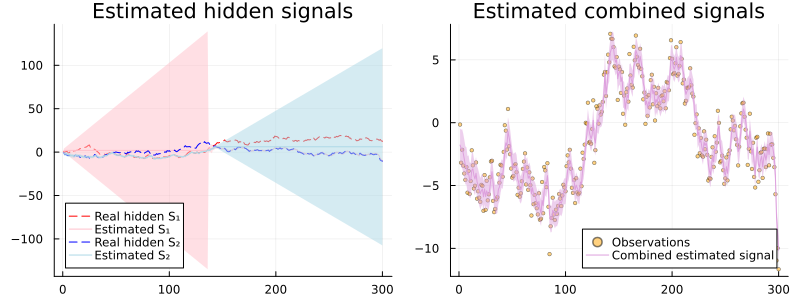

In [48]:
_p1 = plot(legend=:bottomleft, title="Estimated hidden signals")
_p2 = plot(legend=:bottomright, title="Estimated combined signals")

_p1 = plot!(_p1, _rx_s̃₁, label="Real hidden S₁", c=:red, linestyle=:dash)
_p1 = plot!(_p1, mean.(_rx_s₁_marginals), ribbon=var.(_rx_s₁_marginals), label="Estimated S₁", c=:pink)

_p1 = plot!(_p1, _rx_s̃₂, label="Real hidden S₂", c=:blue, linestyle=:dash)
_p1 = plot!(_p1, mean.(_rx_s₂_marginals), ribbon=var.(_rx_s₂_marginals), label="Estimated S₂", c=:lightblue)

_p2 = scatter!(_p2, _rx_y, label="Observations", ms=2, alpha=0.5, color=:orange)
_p2 = plot!(_p2, mean.(_rx_z_marginals), ribbon=std.(_rx_z_marginals), label="Combined estimated signal", color=:plum)

plot(_p1, _p2, size=(800, 300))

The results are quite similar to the smoothing case and, as we can see, one of the random walk is again in the "disabled" state, does not infer anything and simply increases its variance (which is expected for the random walk).